In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\textual_dataset_preprocessed.csv",
    encoding="utf-8"
)

print(df.shape)
print(df.columns.tolist())
print(df.head())

(52408, 12)
['id_registro', 'fonte', 'data_publicacao', 'titulo', 'texto_original', 'nota', 'usuario', 'categoria', 'status', 'sentimento_real', 'texto_limpo', 'data_processamento']
                            id_registro        fonte data_publicacao titulo  \
0  8696d55a-a22a-4f5b-b62c-746b4138ae27  google_play      2026-03-31    NaN   
1  f9ba1b10-d191-412a-b6f6-5b4f6154a9e6  google_play      2026-03-31    NaN   
2  0c72b5e1-e4a7-4cea-9b6f-5a99a72898bc  google_play      2026-03-31    NaN   
3  98eb1147-e329-40ee-ad75-f5ea4fe9c920  google_play      2026-03-31    NaN   
4  9dcfa4ed-2be1-4942-831e-f1afb340f19e  google_play      2026-03-31    NaN   

                                      texto_original  nota usuario categoria  \
0        Amo o Nubank! Ótima experiência. Gratidão 🙏   5.0     NaN       NaN   
1  porque não dá oportunidade de crédito deu uma ...   2.0     NaN       NaN   
2                Muito bom não tenho nada a reclamar   5.0     NaN       NaN   
3                      

In [2]:
df_train = df[df["sentimento_real"].notna()].copy()
df_pred = df[df["sentimento_real"].isna()].copy()

print("Treino:", df_train.shape)
print("Predição:", df_pred.shape)
print(df_train["sentimento_real"].value_counts())
print(df_pred["fonte"].value_counts())

Treino: (38698, 12)
Predição: (13710, 12)
sentimento_real
Positivo    29292
Negativo     7858
Neutro       1548
Name: count, dtype: int64
fonte
youtube    13710
Name: count, dtype: int64


In [3]:
label2id = {
    "Negativo": 0,
    "Neutro": 1,
    "Positivo": 2,
}

id2label = {v: k for k, v in label2id.items()}

df_train["label"] = df_train["sentimento_real"].map(label2id)

print(df_train[["sentimento_real", "label"]].head(10))
print(df_train["label"].value_counts())

  sentimento_real  label
0        Positivo      2
1        Negativo      0
2        Positivo      2
3        Negativo      0
4        Positivo      2
5        Positivo      2
6        Positivo      2
7        Positivo      2
8          Neutro      1
9        Negativo      0
label
2    29292
0     7858
1     1548
Name: count, dtype: int64


In [4]:
label2id = {
    "Negativo": 0,
    "Neutro": 1,
    "Positivo": 2,
}

id2label = {v: k for k, v in label2id.items()}

df_train["label"] = df_train["sentimento_real"].map(label2id)

print(df_train[["sentimento_real", "label"]].head())

  sentimento_real  label
0        Positivo      2
1        Negativo      0
2        Positivo      2
3        Negativo      0
4        Positivo      2


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_train[["texto_original", "label", "sentimento_real"]].copy(),
    test_size=0.2,
    random_state=42,
    stratify=df_train["label"],
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nDistribuição no train:")
print(train_df["sentimento_real"].value_counts())

print("\nDistribuição no test:")
print(test_df["sentimento_real"].value_counts())

Train: (30958, 3)
Test: (7740, 3)

Distribuição no train:
sentimento_real
Positivo    23433
Negativo     6286
Neutro       1239
Name: count, dtype: int64

Distribuição no test:
sentimento_real
Positivo    5859
Negativo    1572
Neutro       309
Name: count, dtype: int64


In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

print("Tokenizer carregado")
print("Modelo carregado")

C:\Users\Lucca\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 49768.44it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.deco

Tokenizer carregado
Modelo carregado


In [7]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
pred_dataset = Dataset.from_pandas(df_pred[["texto_original"]].reset_index(drop=True))

print(train_dataset)
print(test_dataset)
print(pred_dataset)

Dataset({
    features: ['texto_original', 'label', 'sentimento_real'],
    num_rows: 30958
})
Dataset({
    features: ['texto_original', 'label', 'sentimento_real'],
    num_rows: 7740
})
Dataset({
    features: ['texto_original'],
    num_rows: 13710
})


In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["texto_original"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

In [9]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
pred_dataset = pred_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 13710/13710 [00:00<00:00, 24010.46 examples/s]


In [10]:
print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['texto_original', 'label', 'sentimento_real', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30958
})
{'texto_original': 'aminha comta nao tá abrido', 'label': 2, 'sentimento_real': 'Positivo', 'input_ids': [101, 1052, 508, 170, 154, 229, 22280, 16258, 2751, 243, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [11]:
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [12]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

pred_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids"]
)

In [13]:
print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['texto_original', 'labels', 'sentimento_real', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30958
})
{'labels': tensor(2), 'input_ids': tensor([  101,  1052,   508,   170,   154,   229, 22280, 16258,  2751,   243,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     

In [14]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
    }

In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\artifacts\bertimbau",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [17]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.346785,0.317968,0.901938,0.588374
2,0.284639,0.356224,0.900388,0.614812


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]


TrainOutput(global_step=7740, training_loss=0.31571210521136145, metrics={'train_runtime': 371.53, 'train_samples_per_second': 166.651, 'train_steps_per_second': 20.833, 'total_flos': 4072732593011712.0, 'train_loss': 0.31571210521136145, 'epoch': 2.0})

In [18]:
pred_output = trainer.predict(test_dataset)

In [19]:
print(type(pred_output))
print(pred_output.predictions.shape)
print(pred_output.label_ids.shape)
print(pred_output.metrics)

<class 'transformers.trainer_utils.PredictionOutput'>
(7740, 3)
(7740,)
{'test_loss': 0.35622355341911316, 'test_accuracy': 0.9003875968992248, 'test_f1_macro': 0.6148119420330808, 'test_runtime': 13.751, 'test_samples_per_second': 562.868, 'test_steps_per_second': 70.395}


In [20]:
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

print(y_pred[:20])
print(y_true[:20])

[0 2 2 2 2 2 2 2 0 0 2 2 0 2 2 2 2 2 2 2]
[1 2 2 2 2 2 1 2 0 0 2 2 0 2 2 2 2 2 2 2]


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Negativo", "Neutro", "Positivo"]))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

    Negativo       0.76      0.86      0.81      1572
      Neutro       0.27      0.05      0.08       309
    Positivo       0.95      0.96      0.95      5859

    accuracy                           0.90      7740
   macro avg       0.66      0.62      0.61      7740
weighted avg       0.88      0.90      0.89      7740

[[1357   20  195]
 [ 176   15  118]
 [ 242   20 5597]]


In [22]:
pred_youtube_output = trainer.predict(pred_dataset)
youtube_pred_labels = np.argmax(pred_youtube_output.predictions, axis=-1)

df_pred_bert = df_pred.copy()
df_pred_bert["sentimento_previsto_bert"] = [id2label[label] for label in youtube_pred_labels]

print(df_pred_bert["sentimento_previsto_bert"].value_counts())
print(df_pred_bert[["texto_original", "sentimento_previsto_bert"]].head(20))

sentimento_previsto_bert
Positivo    7987
Negativo    5626
Neutro        97
Name: count, dtype: int64
                                       texto_original sentimento_previsto_bert
69              Sou cliente e sou muito bem atendido.                 Positivo
70  Tenho conta nubank e não gostei pq só posso co...                 Negativo
71  A minha amiga quer pegar um dinheiro emprestad...                 Negativo
72    enquanto isso Lulinha so que rouba os velhos 😂😂                 Positivo
73  Assisti curso totalmente didático e gratuito 🎉...                 Positivo
74  Os endividados que eu conheço são os jogadores...                 Negativo
75                                       Opa manda ai                 Positivo
76                                    Sou cliente 👏❤️                 Positivo
77                                  Sou cliente . 👏💯💯                 Positivo
78                                      Sou cliente 😊                 Positivo
79                           

In [23]:
output_path_bert = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_bertimbau.csv"
df_pred_bert.to_csv(output_path_bert, index=False, encoding="utf-8-sig")
print(output_path_bert)

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_bertimbau.csv


In [24]:
pred_youtube_output = trainer.predict(pred_dataset)
youtube_pred_labels = np.argmax(pred_youtube_output.predictions, axis=-1)

df_pred_bert = df_pred.copy()
df_pred_bert["sentimento_previsto_bert"] = [id2label[label] for label in youtube_pred_labels]

print(df_pred_bert["sentimento_previsto_bert"].value_counts())
print(df_pred_bert[["texto_original", "sentimento_previsto_bert"]].head(20))

sentimento_previsto_bert
Positivo    7987
Negativo    5626
Neutro        97
Name: count, dtype: int64
                                       texto_original sentimento_previsto_bert
69              Sou cliente e sou muito bem atendido.                 Positivo
70  Tenho conta nubank e não gostei pq só posso co...                 Negativo
71  A minha amiga quer pegar um dinheiro emprestad...                 Negativo
72    enquanto isso Lulinha so que rouba os velhos 😂😂                 Positivo
73  Assisti curso totalmente didático e gratuito 🎉...                 Positivo
74  Os endividados que eu conheço são os jogadores...                 Negativo
75                                       Opa manda ai                 Positivo
76                                    Sou cliente 👏❤️                 Positivo
77                                  Sou cliente . 👏💯💯                 Positivo
78                                      Sou cliente 😊                 Positivo
79                           

In [25]:
output_path_bert = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_bertimbau.csv"
df_pred_bert.to_csv(output_path_bert, index=False, encoding="utf-8-sig")
print(output_path_bert)

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\youtube_with_predicted_sentiment_bertimbau.csv


In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

classes = [0, 1, 2]
class_names = ["Negativo", "Neutro", "Positivo"]

y_true_bin = label_binarize(y_true, classes=classes)
y_score_bert = pred_output.predictions

print("ROC AUC macro:", roc_auc_score(y_true_bin, y_score_bert, multi_class="ovr", average="macro"))
print("ROC AUC weighted:", roc_auc_score(y_true_bin, y_score_bert, multi_class="ovr", average="weighted"))

ROC AUC macro: 0.9146067150151095
ROC AUC weighted: 0.954830110676174


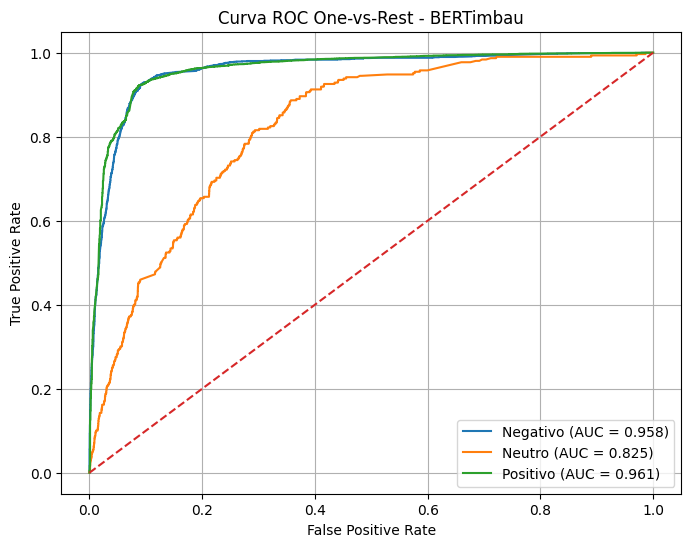

In [27]:
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(class_names):
    fpr[class_name], tpr[class_name], _ = roc_curve(y_true_bin[:, i], y_score_bert[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

plt.figure(figsize=(8, 6))

for class_name in class_names:
    plt.plot(
        fpr[class_name],
        tpr[class_name],
        label=f"{class_name} (AUC = {roc_auc[class_name]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC One-vs-Rest - BERTimbau")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
comparison_rows = [
    {
        "modelo": "LogisticRegression",
        "accuracy": 0.85,
        "f1_macro": 0.63,
        "roc_auc_macro": 0.8791,
        "roc_auc_weighted": 0.9392,
        "f1_negativo": 0.75,
        "f1_neutro": 0.20,
        "f1_positivo": 0.93,
    },
    {
        "modelo": "MultinomialNB",
        "accuracy": 0.88,
        "f1_macro": 0.57,
        "roc_auc_macro": 0.8888,
        "roc_auc_weighted": 0.9393,
        "f1_negativo": 0.77,
        "f1_neutro": 0.00,
        "f1_positivo": 0.94,
    },
    {
        "modelo": "LinearSVC",
        "accuracy": 0.87,
        "f1_macro": 0.62,
        "roc_auc_macro": 0.8607,
        "roc_auc_weighted": 0.9379,
        "f1_negativo": 0.76,
        "f1_neutro": 0.17,
        "f1_positivo": 0.94,
    },
    {
        "modelo": "BERTimbau",
        "accuracy": 0.90,
        "f1_macro": 0.61,
        "roc_auc_macro": 0.9146,
        "roc_auc_weighted": 0.9548,
        "f1_negativo": 0.81,
        "f1_neutro": 0.08,
        "f1_positivo": 0.95,
    },
]

df_compare_final = pd.DataFrame(comparison_rows)

df_compare_final = df_compare_final.sort_values(
    by=["roc_auc_macro", "f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

df_compare_final

,modelo,accuracy,f1_macro,roc_auc_macro,roc_auc_weighted,f1_negativo,f1_neutro,f1_positivo
0,BERTimbau,0.90,0.61,0.9146,0.9548,0.81,0.08,0.95
1,MultinomialNB,0.88,0.57,0.8888,0.9393,0.77,0.00,0.94
2,LogisticRegression,0.85,0.63,0.8791,0.9392,0.75,0.20,0.93
3,LinearSVC,0.87,0.62,0.8607,0.9379,0.76,0.17,0.94


In [29]:
df_compare_final.round(4)

,modelo,accuracy,f1_macro,roc_auc_macro,roc_auc_weighted,f1_negativo,f1_neutro,f1_positivo
0,BERTimbau,0.90,0.61,0.9146,0.9548,0.81,0.08,0.95
1,MultinomialNB,0.88,0.57,0.8888,0.9393,0.77,0.00,0.94
2,LogisticRegression,0.85,0.63,0.8791,0.9392,0.75,0.20,0.93
3,LinearSVC,0.87,0.62,0.8607,0.9379,0.76,0.17,0.94


In [30]:
output_path = r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\model_comparison_summary.csv"
df_compare_final.to_csv(output_path, index=False, encoding="utf-8-sig")
print(output_path)

C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\model_comparison_summary.csv
